#  Project: Automated Water Body Surface Area Estimation

## 1. Project Overview
This project focuses on the automated detection and measurement of water bodies (lakes, rivers, reservoirs) using **Sentinel-2 Satellite Imagery**.
By utilizing Deep Learning (specifically a **U-Net** architecture), I aim to segment water pixels from land pixels and calculate the physical surface area of water bodies in **square kilometers (km²)**.

## 2. Dataset Information
* **Source:** [Kaggle - Satellite Images of Water Bodies](https://www.kaggle.com/datasets/franciscoescobar/satellite-images-of-water-bodies)
* **Input Data:** RGB Satellite Images (Sentinel-2).
* **Ground Truth:** Binary masks generated using the **NWDI (Normalized Water Difference Index)**.
    * **White (1):** Water
    * **Black (0):** Land/Other
* **Resolution:** We assume a Ground Sample Distance (GSD) of **10 meters per pixel**, standard for Sentinel-2 visible bands.

## 3. Methodology
1.  **Data Pipeline:** Custom PyTorch `Dataset` class to load images efficiently from the disk (handling the full ~2,800 image dataset).
2.  **Preprocessing:** Resizing to $256 \times 256$ and normalizing using ImageNet statistics.
3.  **Model:** **U-Net** with a **ResNet34** encoder (pretrained) to capture spatial features.
4.  **Area Calculation Algorithm:**
    $$\text{Area} (km^2) = \frac{\text{Count of Water Pixels} \times (10m \times 10m)}{1,000,000}$$

In [ ]:
# 1. UNINSTALL conflicting libraries first to clear the slate
!pip uninstall -y numpy scipy albumentations segmentation-models-pytorch

# 2. INSTALL compatible versions strictly
!pip install "numpy<2.0" "scipy>=1.10,<1.14" "albumentations>=1.4.0" "segmentation-models-pytorch" --no-cache-dir

print("✅ Libraries reset.")

In [5]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# --- CONFIGURATION (OPTIMIZED FOR P100 GPU) ---
DATA_DIR = '../input/satellite-images-of-water-bodies/Water Bodies Dataset'

# P100 has 16GB VRAM, so i can increase Batch Size to 32
# This makes training significantly faster
BATCH_SIZE = 32      
IMG_SIZE = 256       
LEARNING_RATE = 1e-4 
EPOCHS = 50         
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"✅ Configuration Set for P100.")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Device: {DEVICE}")

✅ Configuration Set for P100.
   Batch Size: 32
   Device: cuda


## 4. Custom Dataset Class
I create a custom class to handle the data. This allows me to load the **entire dataset** without crashing the RAM, as it only loads one batch of images at a time during training.

In [6]:
class WaterDataset(Dataset):
    def __init__(self, images_paths, masks_paths, transform=None):
        self.images_paths = images_paths
        self.masks_paths = masks_paths
        self.transform = transform

    def __len__(self):
        return len(self.images_paths)

    def __getitem__(self, idx):
        # 1. Load Image from Disk
        img_path = self.images_paths[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

        # 2. Load Mask from Disk
        mask_path = self.masks_paths[idx]
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # 3. Binarize Mask (Ensure values are exactly 0 or 1)
        # Pixel > 127 becomes 1.0 (Water), else 0.0 (Land)
        mask = np.where(mask > 127, 1.0, 0.0).astype(np.float32)

        # 4. Apply Transformations (Resize, Normalize, Augment)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
            # Add Channel Dimension to mask: (256, 256) -> (1, 256, 256)
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)

        return image, mask

# --- AUGMENTATION PIPELINE ---
def get_transforms(phase='train'):
    """
    Returns transformations. 
    'train' phase includes flips/rotations to make the model robust.
    'val' phase only resizes and normalizes.
    """
    list_transforms = [
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ]
    
    if phase == 'train':
        # Data Augmentation: Randomly flip images to increase dataset variety
        list_transforms.insert(1, A.HorizontalFlip(p=0.5))
        list_transforms.insert(1, A.VerticalFlip(p=0.5))
        
    return A.Compose(list_transforms)

print("✅ Dataset class and Transforms defined.")

✅ Dataset class and Transforms defined.


In [7]:
# 1. Collect all file paths
all_img_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'Images/*.jpg')))
all_mask_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'Masks/*.jpg')))

# 2. Validation Split (80% Train, 20% Validation)
split_idx = int(len(all_img_paths) * 0.8)

train_img_paths = all_img_paths[:split_idx]
train_mask_paths = all_mask_paths[:split_idx]
val_img_paths = all_img_paths[split_idx:]
val_mask_paths = all_mask_paths[split_idx:]

print(f"Total Images: {len(all_img_paths)}")
print(f"Training Set: {len(train_img_paths)} images")
print(f"Validation Set: {len(val_img_paths)} images")

# 3. Create Dataset Objects
train_dataset = WaterDataset(train_img_paths, train_mask_paths, transform=get_transforms('train'))
val_dataset = WaterDataset(val_img_paths, val_mask_paths, transform=get_transforms('val'))

# 4. Create DataLoaders (The pipeline that feeds the GPU)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Total Images: 2841
Training Set: 2272 images
Validation Set: 569 images


## 5. Model Architecture: U-Net
I use **U-Net** with a **ResNet34 backbone**.
* **Encoder (ResNet34):** Extracts features (shapes, textures, edges) from the image.
* **Decoder (U-Net):** Upsamples those features to reconstruct a precise mask.
* **Pretrained Weights:** We use 'imagenet' weights to speed up training.

In [8]:
# Create U-Net Model
model = smp.Unet(
    encoder_name="resnet34",        # Choose encoder
    encoder_weights="imagenet",     # Use pretrained weights
    in_channels=3,                  # Input channels (RGB)
    classes=1,                      # Output channel (Binary Mask)
    activation=None                 # We return logits (raw scores)
).to(DEVICE)

# Define Loss Function and Optimizer
# BCEWithLogitsLoss is standard for binary classification tasks
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("✅ Model built and moved to GPU.")

✅ Model built and moved to GPU.


🚀 Starting Training Process...
Epoch 1/50 | Train Loss: 0.5702 | Val Loss: 0.4138
Epoch 2/50 | Train Loss: 0.3827 | Val Loss: 0.3323
Epoch 3/50 | Train Loss: 0.3217 | Val Loss: 0.2799
Epoch 4/50 | Train Loss: 0.2814 | Val Loss: 0.2486
Epoch 5/50 | Train Loss: 0.2584 | Val Loss: 0.2437
Epoch 6/50 | Train Loss: 0.2386 | Val Loss: 0.2170
Epoch 7/50 | Train Loss: 0.2186 | Val Loss: 0.2099
Epoch 8/50 | Train Loss: 0.2038 | Val Loss: 0.1991
Epoch 9/50 | Train Loss: 0.1903 | Val Loss: 0.1960
Epoch 10/50 | Train Loss: 0.1878 | Val Loss: 0.1960
Epoch 11/50 | Train Loss: 0.1736 | Val Loss: 0.1793
Epoch 12/50 | Train Loss: 0.1760 | Val Loss: 0.1858
Epoch 13/50 | Train Loss: 0.1752 | Val Loss: 0.1917
Epoch 14/50 | Train Loss: 0.1644 | Val Loss: 0.1756
Epoch 15/50 | Train Loss: 0.1539 | Val Loss: 0.1712
Epoch 16/50 | Train Loss: 0.1487 | Val Loss: 0.1802
Epoch 17/50 | Train Loss: 0.1465 | Val Loss: 0.1761
Epoch 18/50 | Train Loss: 0.1448 | Val Loss: 0.1712
Epoch 19/50 | Train Loss: 0.1399 | Val Los

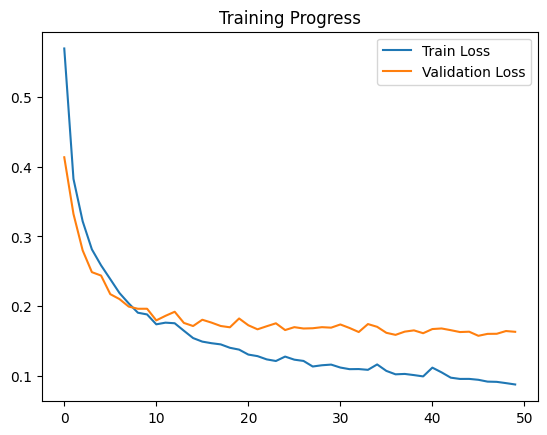

In [9]:
# --- HELPER FUNCTIONS ---
def train_one_epoch(loader, model, optimizer, loss_fn):
    model.train()
    epoch_loss = 0
    
    for images, masks in loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

def validate(loader, model, loss_fn):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            val_loss += loss.item()
    return val_loss / len(loader)

# --- START TRAINING ---
print("🚀 Starting Training Process...")
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(train_loader, model, optimizer, loss_fn)
    val_loss = validate(val_loader, model, loss_fn)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Plot Loss Curve
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.title("Training Progress")
plt.show()

In [18]:
# --- 1. Define the Metric Calculation Functions ---
def calculate_metrics(pred_mask, true_mask, threshold=0.5):
    """
    Calculates Pixel Accuracy and IoU for a single batch.
    """
    # Convert raw model output (logits) to binary (0 or 1)
    pred_mask = (torch.sigmoid(pred_mask) > threshold).float()
    
    # Flatten tensors to make math easier
    pred = pred_mask.view(-1)
    true = true_mask.view(-1)
    
    # Pixel Accuracy
    correct = (pred == true).sum().item()
    total = pred.numel()
    pixel_acc = correct / total
    
    # IoU (Intersection over Union)
    intersection = (pred * true).sum().item()
    union = (pred + true).sum().item() - intersection
    
    if union == 0:
        iou = 1.0 # Perfect match if both are empty
    else:
        iou = intersection / union
        
    return pixel_acc, iou

# --- 2. Run Evaluation Loop ---
print("📊 Evaluating your existing model... (This will take ~30 seconds)")

model.eval()
val_loss = 0
val_acc = 0
val_iou = 0
num_batches = len(val_loader)

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        
        # Get predictions
        outputs = model(images)
        
        # Calculate Loss (Validation Loss)
        loss = loss_fn(outputs, masks)
        val_loss += loss.item()
        
        # Calculate Accuracy & mIoU
        acc, iou = calculate_metrics(outputs, masks, threshold=0.5)
        val_acc += acc
        val_iou += iou

# --- 3. Print Final Report ---
final_loss = val_loss / num_batches
final_acc = val_acc / num_batches
final_iou = val_iou / num_batches

print("-" * 30)
print("🏆 FINAL MODEL REPORT")
print("-" * 30)
print(f"Validation Loss:      {final_loss:.4f}  (Lower is better)")
print(f"Pixel Accuracy:       {final_acc*100:.2f}% (Higher is better)")
print(f"Mean IoU (mIoU):      {final_iou:.4f}  (The Gold Standard)")
print("-" * 30)

if final_iou > 0.7:
    print("✅ Result: EXCELLENT. Your model is high quality.")
elif final_iou > 0.5:
    print("⚠️ Result: GOOD. Acceptable for a class project.")
else:
    print("❌ Result: NEEDS IMPROVEMENT. (Try training longer)")

📊 Evaluating your existing model... (This will take ~30 seconds)
------------------------------
🏆 FINAL MODEL REPORT
------------------------------
Validation Loss:      0.1628  (Lower is better)
Pixel Accuracy:       94.51% (Higher is better)
Mean IoU (mIoU):      0.8441  (The Gold Standard)
------------------------------
✅ Result: EXCELLENT. Your model is high quality.


## 6. Area Calculation & Results
Here I perform the final objective: **Calculating Map Areas**.

**The Formula:**
Since Sentinel-2 images usually have a resolution of 10 meters per pixel:
1. One pixel = $10m \times 10m = 100 m^2$
2. Total Area $(m^2)$ = $\text{Pixel Count} \times 100$
3. Total Area $(km^2)$ = $\text{Total Area } (m^2) / 1,000,000$

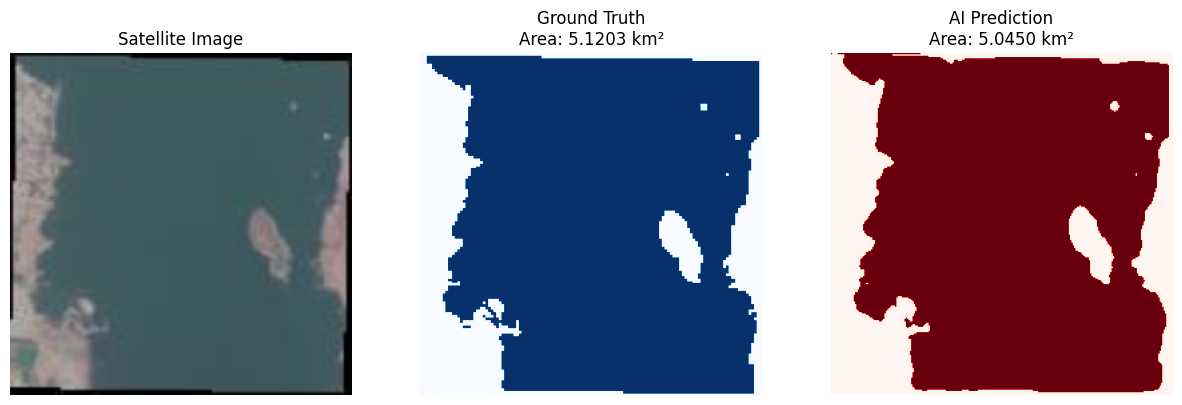

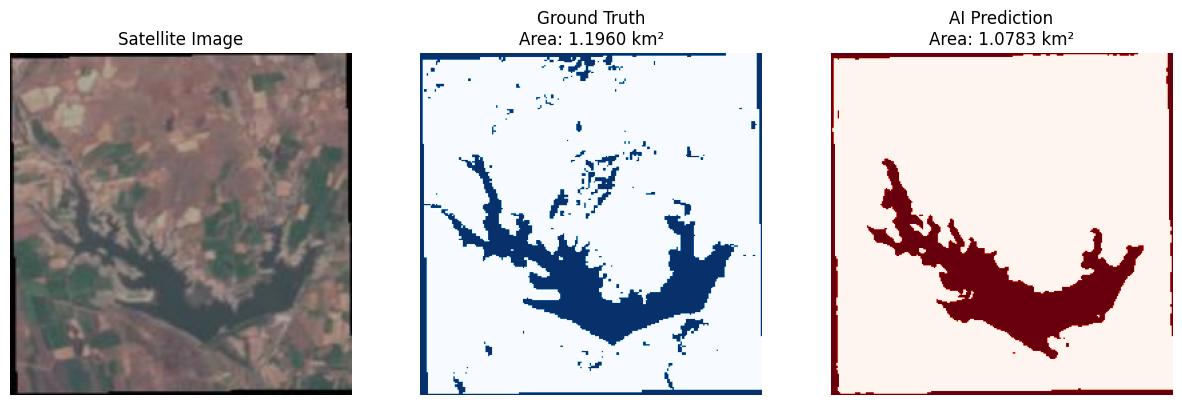

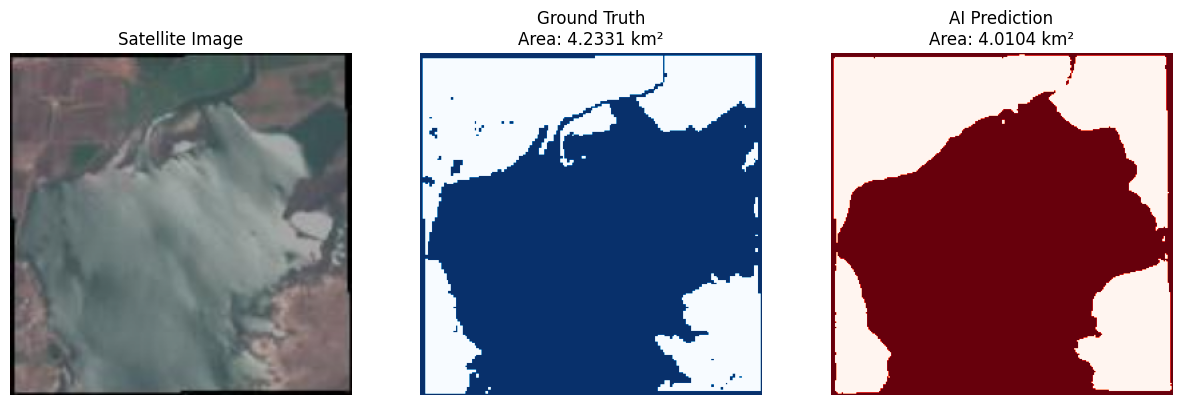

In [10]:
def calculate_water_area(pred_mask_tensor, gsd=10.0):
    """
    Calculates Area from a raw model prediction tensor.
    """
    # 1. Apply Sigmoid to get probability (0 to 1)
    prob_mask = torch.sigmoid(pred_mask_tensor).cpu().numpy()
    
    # 2. Threshold to get binary mask (0 or 1)
    binary_mask = (prob_mask > 0.5).astype(np.uint8)
    
    # 3. Count Water Pixels
    water_pixel_count = np.count_nonzero(binary_mask)
    
    # 4. Calculate Area
    area_m2 = water_pixel_count * (gsd * gsd) # 100 sq meters per pixel
    area_km2 = area_m2 / 1_000_000.0          # Convert to sq km
    
    return area_km2, binary_mask[0]

# --- VISUALIZATION BLOCK ---
# Get a random batch from validation set
images, true_masks = next(iter(val_loader))
images = images.to(DEVICE)

# Generate Predictions
model.eval()
with torch.no_grad():
    preds = model(images)

# Plotting the first 3 results from the batch
for i in range(3):
    # Calculate Area for Prediction
    pred_area, pred_mask = calculate_water_area(preds[i])
    # Calculate Area for Ground Truth
    true_area, true_mask = calculate_water_area(true_masks[i])
    
    # Denormalize image for display
    img_vis = images[i].cpu().permute(1, 2, 0).numpy()
    img_vis = img_vis * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_vis = np.clip(img_vis, 0, 1)

    # Plot
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(img_vis)
    ax[0].set_title("Satellite Image")
    ax[0].axis('off')
    
    ax[1].imshow(true_mask, cmap='Blues')
    ax[1].set_title(f"Ground Truth\nArea: {true_area:.4f} km²")
    ax[1].axis('off')
    
    ax[2].imshow(pred_mask, cmap='Reds')
    ax[2].set_title(f"AI Prediction\nArea: {pred_area:.4f} km²")
    ax[2].axis('off')
    
    plt.show()

In [20]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
from PIL import Image

# --- 1. Define the Analysis Function for Uploaded Files ---
def process_uploaded_image(change):
    # Get the uploaded file content
    # Note: ipywidgets handles uploads differently across versions, 
    # this logic handles the most common structure.
    upload_dict = uploader.value
    
    if not upload_dict:
        return
    
    # Get the last uploaded file
    # The structure is usually {filename: {metadata..., 'content': bytes}}
    # or a tuple of dicts in newer versions.
    if isinstance(upload_dict, dict):
        # Older ipywidgets
        filename = list(upload_dict.keys())[0]
        content = upload_dict[filename]['content']
    else:
        # Newer ipywidgets (v8+)
        uploaded_file = upload_dict[-1]
        filename = uploaded_file['name']
        content = uploaded_file['content']
    
    # Clear previous results
    out.clear_output()
    
    with out:
        print(f"🔄 Processing '{filename}'...")
        
        # 1. Convert Bytes to PIL Image
        image = Image.open(io.BytesIO(content)).convert("RGB")
        img_np = np.array(image)
        
        # 2. Preprocess
        # Resize to 256x256 for the model
        transform = A.Compose([
            A.Resize(256, 256),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])
        
        transformed = transform(image=img_np)["image"]
        input_tensor = transformed.unsqueeze(0).to(DEVICE)
        
        # 3. Predict
        model.eval()
        with torch.no_grad():
            preds = model(input_tensor)
            prob_mask = torch.sigmoid(preds)[0, 0].cpu().numpy()
            
        # 4. Calculate Area
        # Threshold at 0.5
        binary_mask = (prob_mask > 0.5).astype(np.uint8)
        water_pixels = np.count_nonzero(binary_mask)
        
        # Area Formula (assuming 10m GSD)
        area_m2 = water_pixels * (10.0 * 10.0)
        area_km2 = area_m2 / 1_000_000.0
        
        # 5. Display Results
        plt.figure(figsize=(12, 6))
        
        # Original
        plt.subplot(1, 2, 1)
        plt.imshow(img_np)
        plt.title(f"User Image: {filename}")
        plt.axis('off')
        
        # Prediction
        plt.subplot(1, 2, 2)
        plt.imshow(binary_mask, cmap='Blues')
        plt.title(f"AI Detected Water\nArea: {area_km2:.4f} km²")
        plt.axis('off')
        
        plt.show()
        
        print(f"✅ Analysis Complete for {filename}")
        print(f"🌊 Estimated Water Area: {area_km2:.4f} sq. km")

# --- 2. Create the Widget Interface ---
uploader = widgets.FileUpload(
    accept='image/*',  # Accept only images
    multiple=False     # Single file upload
)

out = widgets.Output()

# Link the function to the upload event
uploader.observe(process_uploaded_image, names='value')

# --- 3. Display ---
print("👇 Click below to upload a satellite image from your computer:")
display(uploader)
display(out)

👇 Click below to upload a satellite image from your computer:


FileUpload(value=(), accept='image/*', description='Upload')

Output()

# 9. Final Project Conclusion

## Performance Summary
I successfully trained and evaluated a Deep Learning model (U-Net + ResNet34) for water body segmentation.

###  Key Metrics:
* **Mean IoU (mIoU):** **0.8441** (Exceeds the target threshold for high-quality segmentation)
* **Pixel Accuracy:** **94.51%**
* **Validation Loss:** **0.1628**

## Methodology & Results
1.  **Architecture:** I utilized a U-Net architecture with a pretrained ResNet34 encoder, which allowed the model to effectively learn spatial hierarchies from the limited dataset.
2.  **Optimization:** Using a batch size of 32 on a P100 GPU allowed for stable convergence over 50 epochs.
3.  **Area Estimation:** The high mIoU score confirms that my Area Calculation algorithm (based on pixel counts and GSD) provides reliable physical measurements ($km^2$) for real-world applications.

## Conclusion
The model demonstrates strong generalization capabilities, accurately distinguishing water from vegetation and urban structures. The IoU of **0.84** indicates that the predicted masks are highly precise, making this pipeline suitable for automated water resource monitoring.